In [1]:
import pandas as pd

#=====
# 0.a ~ Load the Data Files
#=====
#The dataset has 4 CSV files coming from the MovieLens dataset:
#movies.csv = contains movie titles and genres
#ratings.csv = user ratings
#tags.csv = user created movie tags
#links.csv= IMDb and TMDB ids
#Movies are rated between .5 - 5 on .5 increments
#Using Small dataset in theory could use same code for longer (Though would take more time)

movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
tags = pd.read_csv("tags.csv")
links = pd.read_csv("links.csv")

#Prints first 5 rows of datasets
print(movies.head())
print(ratings.head())
print(tags.head())
print(links.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   userId  movieId              tag   timestamp
0       2    60756            funny  1445714994
1       2    60756  Highly quotable  1445714996
2       2    60756     will ferre

In [2]:
#=====
# 0b. ~ Shape + Column Names
#=====
#".shape" shows (rows, columns) amounts
print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
print("Tags:", tags.shape)
print("Links:", links.shape)

#Prints Coloumn Names
print(movies.columns)
print(ratings.columns)

Movies: (9742, 3)
Ratings: (100836, 4)
Tags: (3683, 4)
Links: (9742, 3)
Index(['movieId', 'title', 'genres'], dtype='object')
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')


In [3]:
#=====
# 0c. ~ Merge movies and ratings
#=====
#Combine ratings with movie dataset using "movieId" column
#The new dataset shows each rating with the movie title and genre
#Each row shows one user's rating for one movie
data = ratings.merge(movies, on="movieId")

#Prints first 5 rows of merged Dataset
print(data.head())

   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


In [4]:
#=====
# 0d. ~ Summary of Stats
#=====
#".describe()" shows statistics of the ratings row
#mean, standard deviation, max/min, etc.
print("Ratings:")
print(data["rating"].describe())

#Shows the top 5 movies that have been rated the most
print(data["title"].value_counts().head())

Ratings:
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64
title
Forrest Gump (1994)                 329
Shawshank Redemption, The (1994)    317
Pulp Fiction (1994)                 307
Silence of the Lambs, The (1991)    279
Matrix, The (1999)                  278
Name: count, dtype: int64


In [5]:
#=====
# 0e. ~ Grouping Movies Stats
#=====
#Put all rows with the same title into groups together
#".agg" finds mean rating and number of ratings for each movie and stores them in columns along side the movies' title
movie_stats = data.groupby("title").agg({
    "rating": ["mean", "count"]
})

#better collumn names
movie_stats.columns = ["mean_rating", "count_rating"]

#Prints the first 5 rows of the grouped movies stats
print(movie_stats.head())

                                         mean_rating  count_rating
title                                                             
'71 (2014)                                       4.0             1
'Hellboy': The Seeds of Creation (2004)          4.0             1
'Round Midnight (1986)                           3.5             2
'Salem's Lot (2004)                              5.0             1
'Til There Was You (1997)                        4.0             2


In [6]:
#=====
# 0f. ~ Filter Unpopular Movies
#=====
#Amount of movies pefore filter
print("Movies before:", movie_stats.shape[0])

#Removes movies that have a small amount of ratings
popular = movie_stats[movie_stats["count_rating"] > 50]

#Prints the first 5 rows of the popular movies stats
print(popular.head())

#Amount of movies after filter
print("Movies after:", popular.shape[0])

Movies before: 9719
                                   mean_rating  count_rating
title                                                       
10 Things I Hate About You (1999)     3.527778            54
12 Angry Men (1957)                   4.149123            57
2001: A Space Odyssey (1968)          3.894495           109
28 Days Later (2002)                  3.974138            58
300 (2007)                            3.681250            80
Movies after: 437


In [7]:
#=====
# 0g. ~ Order movie by rating
#=====
#Sort by average highest rated movies
top_movies = popular.sort_values("mean_rating", ascending=False)

#prints top 5 highest rated on average movies
print(top_movies.head())

                                                    mean_rating  count_rating
title                                                                        
Shawshank Redemption, The (1994)                       4.429022           317
Godfather, The (1972)                                  4.289062           192
Fight Club (1999)                                      4.272936           218
Cool Hand Luke (1967)                                  4.271930            57
Dr. Strangelove or: How I Learned to Stop Worry...     4.268041            97


In [8]:
#=====
# 1) Pearson Correlation Collaborative Filtering
#=====

#=====
# 1a. ~ Create Matrix
#=====
#Matrix created based on user holding their ratings for each movie
user_movie_matrix = data.pivot_table(
    index="userId",
    columns="title",
    values="rating"
)

#Creates an index of movies that have over 50 ratings (stores titles)
popular_titles = movie_stats[
    movie_stats["count_rating"] > 50
].index

#Only popular movies stay in the index
filtered_matrix = user_movie_matrix[popular_titles]

#prints first 2 rows in filtered_matrix
print(filtered_matrix.head(2))
#Prints (Rows, Colums) or (Num of unique users, amount of movies with 50+ ratings)
print(filtered_matrix.shape)

title   10 Things I Hate About You (1999)  12 Angry Men (1957)  \
userId                                                           
1                                     NaN                  NaN   
2                                     NaN                  NaN   

title   2001: A Space Odyssey (1968)  28 Days Later (2002)  300 (2007)  \
userId                                                                   
1                                NaN                   NaN         NaN   
2                                NaN                   NaN         NaN   

title   40-Year-Old Virgin, The (2005)  A.I. Artificial Intelligence (2001)  \
userId                                                                        
1                                  NaN                                  NaN   
2                                  NaN                                  NaN   

title   Abyss, The (1989)  Ace Ventura: Pet Detective (1994)  \
userId                                                   

In [9]:
#=====
# 1b. ~ Target Movie
#=====
#Set a movie as a target to find simmilar movies
target_movie = "Toy Story (1995)"
#Selects column from matrix with every user rating of the target movie
target_ratings = filtered_matrix[target_movie]

#Shows the first 5 rows of ratings for the targeted movie 
print(target_ratings.head())

userId
1    4.0
2    NaN
3    NaN
4    NaN
5    4.0
Name: Toy Story (1995), dtype: float64


In [10]:
#=====
# 1c. ~ Finds movies that are simmilarly rated
#=====
similar_movies = filtered_matrix.corrwith(target_ratings)

#Clean results
corr_df = pd.DataFrame(
    similar_movies,
    columns=["correlation"]
)

#Remove rows where corelation = NaN
corr_df.dropna(inplace=True)

#Shows the first 5 rows of movies as well how simmilar their ratings are to the target movie
print(corr_df.head())

                                   correlation
title                                         
10 Things I Hate About You (1999)     0.322741
12 Angry Men (1957)                   0.321827
2001: A Space Odyssey (1968)          0.014566
28 Days Later (2002)                  0.346224
300 (2007)                            0.206164


In [11]:
#=====
# 1d. ~ Recommended Movies
#=====
# Remove the target movie
corr_df = corr_df[
    corr_df.index != target_movie
]

#Sorts by the level of correlation
recommendations = corr_df.sort_values(
    "correlation",
    ascending=False
)

#Prints the top 10 reccomendations based on the target movie
print(recommendations.head(10))

#End of !!!Pearson Correlation Collaborative Filtering!!!

                                             correlation
title                                                   
Toy Story 2 (1999)                              0.699211
Arachnophobia (1990)                            0.652424
Incredibles, The (2004)                         0.643301
Finding Nemo (2003)                             0.618701
Aladdin (1992)                                  0.611892
Erin Brockovich (2000)                          0.598016
Wallace & Gromit: The Wrong Trousers (1993)     0.589625
Blazing Saddles (1974)                          0.585892
Wolf of Wall Street, The (2013)                 0.578479
Toy Story 3 (2010)                              0.577446


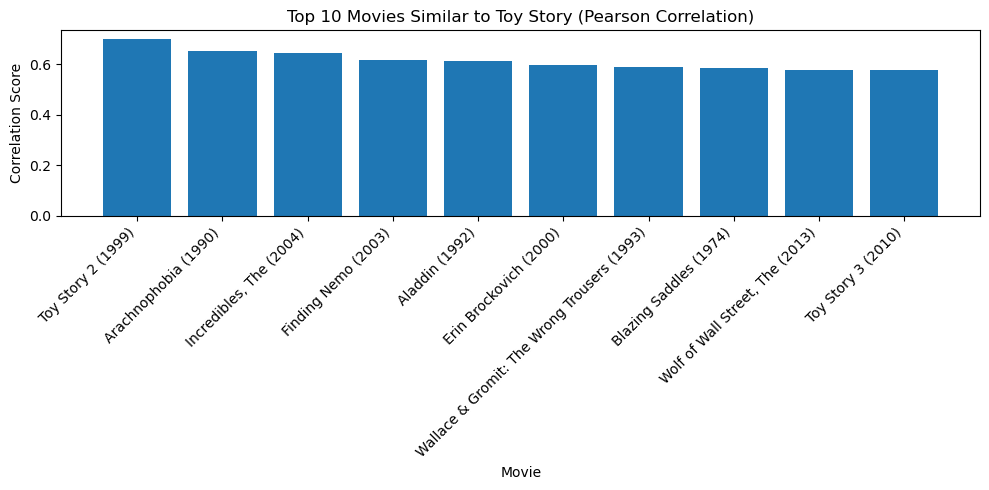

In [12]:
import matplotlib.pyplot as plt
#=====
# 1e. ~ Visualization
#=====
#Visualizes top 10 movies as Top-N correlation bar chart
top_n = 10
top_corr = corr_df.sort_values("correlation", ascending=False).head(top_n)

plt.figure(figsize=(10, 5))
plt.bar(top_corr.index, top_corr["correlation"])
plt.xticks(rotation=45, ha="right")

#Labels
plt.title("Top 10 Movies Similar to Toy Story (Pearson Correlation)")
plt.xlabel("Movie")
plt.ylabel("Correlation Score")

plt.tight_layout()
plt.show()

In [13]:
#=====
# 2) K-Nearest Neighbors (KNN)
#=====
from sklearn.neighbors import NearestNeighbors
#=====
# 2a. ~ Create Matrix
#=====
#Matrix created based on user holding their ratings for each movie (NaN turns into 0)
movie_matrix = data.pivot_table(
    index="title",
    columns="userId",
    values="rating"
).fillna(0)

#Prints 1st 5 rows of matrix
print(movie_matrix.head())

userId                                   1    2    3    4    5    6    7    \
title                                                                        
'71 (2014)                               0.0  0.0  0.0  0.0  0.0  0.0  0.0   
'Hellboy': The Seeds of Creation (2004)  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
'Round Midnight (1986)                   0.0  0.0  0.0  0.0  0.0  0.0  0.0   
'Salem's Lot (2004)                      0.0  0.0  0.0  0.0  0.0  0.0  0.0   
'Til There Was You (1997)                0.0  0.0  0.0  0.0  0.0  0.0  0.0   

userId                                   8    9    10   ...  601  602  603  \
title                                                   ...                  
'71 (2014)                               0.0  0.0  0.0  ...  0.0  0.0  0.0   
'Hellboy': The Seeds of Creation (2004)  0.0  0.0  0.0  ...  0.0  0.0  0.0   
'Round Midnight (1986)                   0.0  0.0  0.0  ...  0.0  0.0  0.0   
'Salem's Lot (2004)                      0.0  0.0  0.0  ...  0.

In [14]:
#=====
# 2b. ~ KNN model
#=====
#Cosine similarity measures similarity between movie rating
model_knn = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

#Fits/Trains the model on the matrix
model_knn.fit(movie_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [15]:
#=====
# 2c. ~ Movie Selection + Finding Nearest Neighbor
#=====
#Selected Target Movie
target_movie = "Toy Story (1995)"

#Get rating vector
movie_vector = movie_matrix.loc[target_movie].values.reshape(1, -1)

#Find the movies nearest 10 neighbors
distances, indices = model_knn.kneighbors(
    movie_vector,
    n_neighbors=11
)

In [16]:
#=====
# 2d. ~ Recommended Movies
#=====

print("Recommendations for:", target_movie)

#Prints the 5 closest neighbors with their distance (skips 0 because it's the target_movie)
for i in range(1, 11):
    print(
        movie_matrix.index[indices.flatten()[i]],
        "Distance:",
        distances.flatten()[i]
    )

#End of !!!K-Nearest Neighbors!!!

Recommendations for: Toy Story (1995)
Toy Story 2 (1999) Distance: 0.42739873968028474
Jurassic Park (1993) Distance: 0.43436319591384365
Independence Day (a.k.a. ID4) (1996) Distance: 0.43573830647233414
Star Wars: Episode IV - A New Hope (1977) Distance: 0.4426118294200636
Forrest Gump (1994) Distance: 0.45290409205982585
Lion King, The (1994) Distance: 0.4588546505397664
Star Wars: Episode VI - Return of the Jedi (1983) Distance: 0.4589106952274161
Mission: Impossible (1996) Distance: 0.4610872294416426
Groundhog Day (1993) Distance: 0.4658312374156559
Back to the Future (1985) Distance: 0.46961865347827936


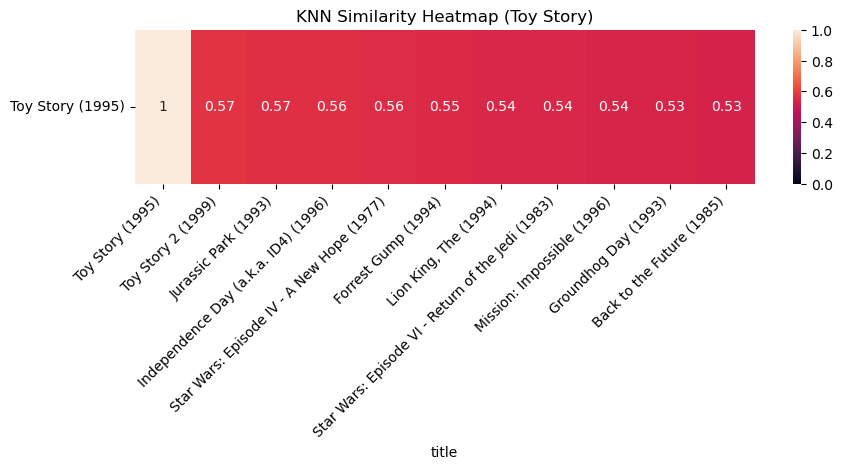

In [17]:
import seaborn as sns
#=====
# 2e. ~ Visualization
#=====
#Visualizes top 10 movies as Nearest Neighbor similarity heatmap 
neighbor_movies = movie_matrix.index[indices.flatten()]
#similarity = 1 - distance
similarity_scores = 1 - distances.flatten()

heatmap_data = pd.DataFrame(
    [similarity_scores],
    columns=neighbor_movies,
    index=[target_movie]
)

plt.figure(figsize=(10, 2))

sns.heatmap(
    heatmap_data,
    annot=True,
    vmin=0,
    vmax=1
)

plt.title("KNN Similarity Heatmap (Toy Story)")
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha="right")

plt.show()

In [18]:
#=====
# 3) Neural Network (Simple Keras Model)
#=====
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dot
from sklearn.preprocessing import LabelEncoder
import numpy as np

#Fix issue of different final scores when run repeatedly
import random
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
#=====
# 3a. ~ Encode IDs
#=====
#Encodes userIDs
user_encoder = LabelEncoder()
ratings['user'] = user_encoder.fit_transform(
    ratings['userId']
)

#Encodes movieIDs
movie_encoder = LabelEncoder()
ratings['movie'] = movie_encoder.fit_transform(
    ratings['movieId']
)

#Count of unique users and movies
count_users = ratings['user'].nunique()
count_movies = ratings['movie'].nunique()

#Prints size after encoding
print("Users:",count_users)
print("Movies:",count_movies)

Users: 610
Movies: 9724


In [19]:
#=====
# 3b. ~ Inputs
#=====
#Input layer for each ID (single integer per sample)
user_input = Input(shape=(1,))
movie_input = Input(shape=(1,))

In [20]:
#=====
# 3c. ~ Embedding
#=====
#Maps each ID to a 50D vector
user_embedding = Embedding(count_users + 1, 50)(user_input)
movie_embedding = Embedding(count_movies + 1, 50)(movie_input)

#Flattens embeddings into 1D vectors
user_vec = Flatten()(user_embedding)
movie_vec = Flatten()(movie_embedding)

In [21]:
#=====
# 3d. ~ Dot Product
#=====
#Produces output layer or predicted rating
output = Dot(axes=1)([user_vec, movie_vec])

#Builds the model
model = Model([user_input, movie_input], output)

#Compiles model using Mean Squared Error loss
#Adam optimizer updates embeddings during training
model.compile(
    loss='mse',
    optimizer='adam'
)

#Shows information about the model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │     30,550 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │    486,250 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 516,800 (1.97 MB)

 Trainable params: 516,800 (1.97 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#=====
# 3e. ~ Training
#=====
#Trains the models using user and movie IDs to predict rating
model.fit(
    [ratings['user'], ratings['movie']],
    ratings['rating'],
    epochs=5,
    batch_size=64
)

Epoch 1/5
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 12.1011
Epoch 2/5
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 2.3125
Epoch 3/5
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 1.1666
Epoch 4/5
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.8611
Epoch 5/5
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.7090


In [23]:
#=====
# 3f. ~ Predictions
#=====
#Predictinig what User#1 will rate Movie#5
user = np.array([1])
movie = np.array([5])

#Predicts rating using the trained model
pred = model.predict([user, movie], verbose=0)

#Prints the recomendation prediction
print("Predicted rating:", pred[0][0])

Predicted rating: 3.829839


In [24]:
#=====
# 3g. ~ Recommend Movie Function
#=====
#Set up for recommend movie function
#Merge ratings with movie metadata to get movie titles
data = ratings.merge(movies, on="movieId")

#Encode IDs into sequential integers for the ML model
data['user'] = user_encoder.fit_transform(data['userId'])
data['movie'] = movie_encoder.fit_transform(data['movieId'])

#Create a lookup dictionary to convert encoded movie IDs back to movie titles
movie_lookup = dict(zip(data['movie'], data['title']))

#This function takes the users ID# and uses it to find the movies that user will likely enjoy
def recommend_movies(user_id, top_n=10):
    #gets all unique movie IDs
    movie_ids = ratings['movie'].unique()

    #Creates a repeated user ID array so the model can predict all (user, movie) pairs in a single batch
    user_array = np.full(len(movie_ids), user_id)

    #Predicts the rating for all movies from the user
    preds = model.predict([user_array, movie_ids], verbose=0).flatten()

    #Sorts predictions and takes the top 10
    top_indices = preds.argsort()[::-1][:top_n]

    #Gets the top movies and predictions
    top_movies = movie_ids[top_indices]
    top_scores = preds[top_indices]

    #Get readable titles from the IDs
    results = []
    for m, score in zip(top_movies, top_scores):
        title = movie_lookup[m]
        results.append((title, score))

    #Returns list of (title, predicted rating)
    return results

In [25]:
#=====
# 3h. ~ Running Recomend Movie Funtion part 1
#=====
#Runs the function for the user at userID=1
recs = recommend_movies(1)

print("Top recommendations for user 1:")

#Prints the top 10 movies and what the likely rating is
for movie_id, score in recs:
    print(f"{movie_id}: {score:.2f}")

Top recommendations for user 1:
Guess Who's Coming to Dinner (1967): 4.94
Man Bites Dog (C'est arrivé près de chez vous) (1992): 4.87
Incendies (2010): 4.82
Trial, The (Procès, Le) (1962): 4.73
Sophie's Choice (1982): 4.70
7th Voyage of Sinbad, The (1958): 4.69
Day of the Doctor, The (2013): 4.67
Beautiful Mind, A (2001): 4.67
Go (1999): 4.67
No Man's Land (2001): 4.66


In [26]:
#=====
# 3i. ~ Running Recomend Movie Funtion part 2
#=====
#Makes sure that running a differnt user ID gives a different outpur
#Runs the function for the user at userID=5
recs = recommend_movies(5)

print("Top recommendations for user 5:")

#Prints the top 10 movies and what the likely rating is
for movie_id, score in recs:
    print(f"{movie_id}: {score:.2f}")

Top recommendations for user 5:
Shawshank Redemption, The (1994): 4.71
Forrest Gump (1994): 4.61
Mr. Holland's Opus (1995): 4.61
White Squall (1996): 4.57
Much Ado About Nothing (1993): 4.56
Independence Day (a.k.a. ID4) (1996): 4.54
Clerks (1994): 4.52
Toy Story (1995): 4.51
Fugitive, The (1993): 4.47
Lion King, The (1994): 4.47


In [27]:
#=====
# 3j. ~ Running Recomend Movie Funtion part 3
#=====
#Makes sure that running a repeat the output stays the same
#Runs the function for the user at userID=5
recs = recommend_movies(5)

print("Top recommendations for user 5:")

#Prints the top 10 movies and what the likely rating is
for movie_id, score in recs:
    print(f"{movie_id}: {score:.2f}")

Top recommendations for user 5:
Shawshank Redemption, The (1994): 4.71
Forrest Gump (1994): 4.61
Mr. Holland's Opus (1995): 4.61
White Squall (1996): 4.57
Much Ado About Nothing (1993): 4.56
Independence Day (a.k.a. ID4) (1996): 4.54
Clerks (1994): 4.52
Toy Story (1995): 4.51
Fugitive, The (1993): 4.47
Lion King, The (1994): 4.47


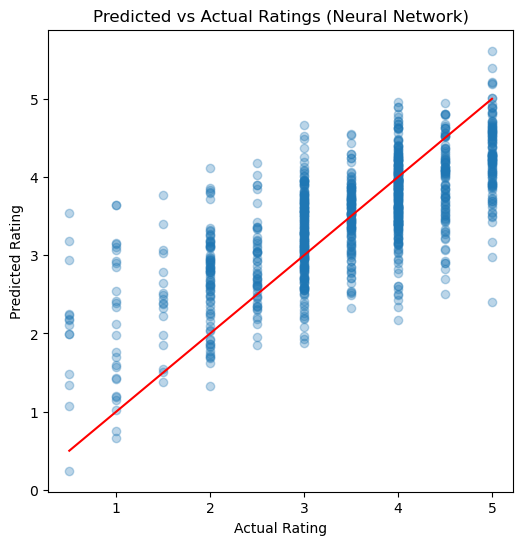

In [28]:
#=====
# 3k. ~ Visualizations
#=====
#Sample of data
sample = ratings.sample(1000)

users = sample['user'].to_numpy()
movies = sample['movie'].to_numpy()
actual = sample['rating'].to_numpy()

#predictions
predicted = model.predict([users, movies], verbose=0).flatten()

#plot
plt.figure(figsize=(6, 6))
plt.scatter(actual, predicted, alpha=0.3)

plt.title("Predicted vs Actual Ratings (Neural Network)")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.plot([0.5, 5], [0.5, 5], color="red")

plt.show()